## Assignment 1
### Name: Ishan Jogalekar 
### ID: 2025ag05864
### Subject code and Name: AIMLZG511, DNN

### Dataset Selection

Dataset: Air Quality Dataset: Indian Cities (2022-2025) <br>
Link: https://www.kaggle.com/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025 <br>
Source: Kaggle 

---

Details: <br>
Samples: Total - 842,160 hourly observations | Considered -40,000 for model training and testing <br>
Features: 62 <br>
Target: US_AQI <br>

---

### Objective
The objective of this assignment is to:

 - Implement a baseline Linear Regression model, MLP, Logistic Regression model and SoftMax multi-class Regression from scratch 
 - Compare their performance on test data
 - Analyze the results for each model

--- 

### Models Implemented:
- Linear Regression (Baseline)
- Logistic Regression (Binary Classification)
- Softmax Regression (Multi-class)
- Multi-Layer Perceptron (MLP)

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
# Set seaborn plotting board 
sns.set(style="whitegrid", palette="deep", font_scale=1.2)

## Tasks
- Predict AQI (Regression)
- Predict Rain (Binary)
- Predict AQI Category (Multiclass)

In [3]:
# Load dataset
df = pd.read_csv("Dataset/INDIA_AQI_COMPLETE_20251126.csv")
df.columns = df.columns.str.lower()

# Remove columns with all NaN
df = df.dropna(axis=1, how='all')

# Remove constant columns (zero variance)
df = df.loc[:, df.nunique() > 1]
print("Shape:", df.shape)

Shape: (842160, 62)


In [4]:
# Take only 20,000 samples for faster training
df = df.sample(n=40000, random_state=42).reset_index(drop=True)

print("New Shape:", df.shape)

New Shape: (40000, 62)


In [5]:
# Basic Info about dataset
print(df.head())

print("\nSummary:")
display(df.describe())

                 city        state  latitude  longitude             datetime  \
0         Bhubaneswar       Odisha   20.2961    85.8245  2024-04-15 07:00:00   
1             Kolkata  West Bengal   22.5726    88.3639  2024-09-28 15:00:00   
2            Gurugram      Haryana   28.4595    77.0266  2022-12-14 17:00:00   
3  Thiruvananthapuram       Kerala    8.5241    76.9366  2023-10-13 07:00:00   
4              Jaipur    Rajasthan   26.9124    75.7873  2024-10-07 06:00:00   

   year  month  day  hour  day_of_week  ... us_aqi_no2  us_aqi_o3  us_aqi_co  \
0  2024      4   15     7            0  ...        3.0       36.0          4   
1  2024      9   28    15            5  ...        3.0       32.0          2   
2  2022     12   14    17            2  ...        0.0       14.0          1   
3  2023     10   13     7            4  ...        3.0       19.0          2   
4  2024     10    7     6            0  ...       11.0       15.0          5   

   eu_aqi eu_aqi_pm25 eu_aqi_pm10     

,latitude,longitude,year,month,day,hour,day_of_week,week_of_year,is_weekend,quarter,...,us_aqi_pm25,us_aqi_pm10,us_aqi_no2,us_aqi_o3,us_aqi_co,eu_aqi,eu_aqi_pm25,eu_aqi_pm10,festival_period,crop_burning_season
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,...,39994.000000,39994.000000,40000.000000,39999.000000,40000.000000,39994.000000,39994.000000,39994.000000,40000.000000,40000.000000
mean,23.112884,82.785576,2023.725875,6.793950,15.704050,11.508475,2.997425,27.739350,0.286100,2.599875,...,91.214382,44.211757,7.997725,45.142729,4.345000,62.446817,57.943141,48.080087,0.104900,0.197975
std,5.532330,6.923040,0.993456,3.417453,8.767211,6.925188,1.998179,14.875718,0.451942,1.114049,...,44.246602,55.868190,10.340580,35.307537,3.777086,37.186054,31.450511,36.428772,0.306428,0.398478
min,8.524100,72.571400,2022.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,2.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,1.000000,0.000000,0.000000
25%,20.296100,77.173400,2023.000000,4.000000,8.000000,6.000000,1.000000,15.000000,0.000000,2.000000,...,58.000000,21.000000,2.000000,24.000000,2.000000,36.000000,31.000000,23.000000,0.000000,0.000000
50%,23.831500,80.946200,2024.000000,7.000000,16.000000,12.000000,3.000000,29.000000,0.000000,3.000000,...,81.000000,36.000000,4.000000,35.000000,3.000000,62.000000,61.000000,40.000000,0.000000,0.000000
75%,26.912400,88.606500,2025.000000,10.000000,23.000000,17.000000,5.000000,41.000000,1.000000,4.000000,...,122.000000,56.000000,10.000000,49.000000,5.000000,77.000000,75.000000,67.000000,0.000000,0.000000
max,31.104800,94.108600,2025.000000,12.000000,31.000000,23.000000,6.000000,52.000000,1.000000,4.000000,...,355.000000,2586.000000,107.000000,298.000000,80.000000,1116.000000,284.000000,1116.000000,1.000000,1.000000


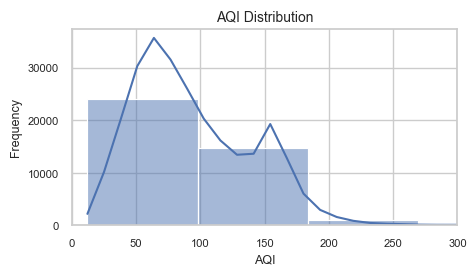

In [6]:
# AQI distribution

plt.figure(figsize=(5,3))  # smaller size

sns.histplot(df["us_aqi"], kde=True, bins=30)

plt.xlim(0, 300) 
plt.title("AQI Distribution", fontsize=10)
plt.xlabel("AQI", fontsize=9)
plt.ylabel("Frequency", fontsize=9)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

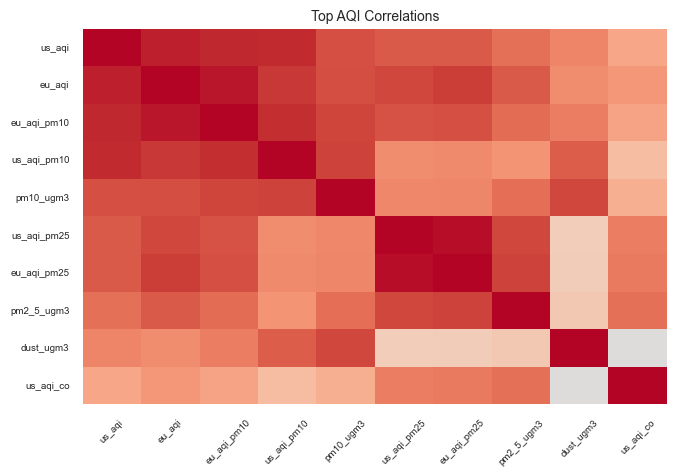

In [7]:
# Correlation heatmap

corr = df.corr(numeric_only=True)
top_features = corr["us_aqi"].abs().sort_values(ascending=False).index[:10]

plt.figure(figsize=(7,5))  # smaller heatmap

sns.heatmap(
    df[top_features].corr(),
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    cbar=False  # remove colorbar to save space
)
plt.title("Top AQI Correlations", fontsize=10)
plt.xticks(fontsize=7, rotation=45)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

In [8]:
# Cleaning of data-set by dropping unwanted columns 
drop_cols = [
    "us_aqi_pm25","us_aqi_pm10","us_aqi_no2",
    "us_aqi_o3","us_aqi_co","eu_aqi","aqi_category"
]

df = df.drop(columns=drop_cols, errors="ignore")
df = df.drop(columns=["city","state","datetime","day_name"], errors="ignore")


# Setting categorical columns for encoding
categorical_cols = [
    "season","time_of_day","humidity_category",
    "wind_category","pm25_category_india",
    "is_weekend","is_raining","heavy_rain",
    "is_daytime","festival_period","crop_burning_season"
]

encoders = {}
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le   # store encoder

# cleaning NaN data
df = df.fillna(df.mean(numeric_only=True))

print("Final Shape:", df.shape)

Final Shape: (40000, 51)


### Train-test split

In [9]:
# Multi-class categorization function
def multi_class(aqi):
    if aqi <= 50:
        return 0
    elif aqi <= 100:
        return 1
    else:
        return 2
        
X = df.drop(columns=["us_aqi"])

# Tragets
y_reg = df["us_aqi"].values.reshape(-1,1)
y_binary = (df["us_aqi"] > 100).astype(int).values.reshape(-1,1)
y_multi = df["us_aqi"].apply(multi_class).values.reshape(-1,1)


# Train-test split (80-20)
X_train, X_test, y_reg_train, y_reg_test, y_bin_train, y_bin_test, y_mul_train, y_mul_test = train_test_split(
    X, y_reg, y_binary, y_multi,
    test_size=0.2,
    random_state=42
)

# Scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_features = X_train.shape[1]

## Linear Regression

In [10]:
class LinearRegressionScratch:
    def __init__(self, lr=0.01, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def fit(self,X,y):
        n,d = X.shape
        self.W = np.zeros((d,1))
        self.b = 0

        for epoch in range(self.epochs):
            pred = X@self.W + self.b
            loss = np.mean((pred-y)**2)
            self.loss_history.append(loss)

            if epoch % 50 == 0:
                print(f"[Linear] Epoch {epoch}, Loss: {loss:.4f}")

            dW = (2/n)*X.T@(pred-y)
            db = (2/n)*np.sum(pred-y)

            self.W -= self.lr*dW
            self.b -= self.lr*db

    def predict(self,X):
        return X@self.W+self.b

## Simple MLP 

In [11]:
class MLP:
    def __init__(self, layers, lr=0.01, epochs=500):
        self.layers = layers
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []
        self.init_params()

    def init_params(self):
        self.params={}
        for i in range(1,len(self.layers)):
            self.params[f"W{i}"] = np.random.randn(
                self.layers[i-1], self.layers[i])*0.01
            self.params[f"b{i}"] = np.zeros((1,self.layers[i]))

    def relu(self,z): return np.maximum(0,z)
    def relu_deriv(self,z): return (z>0)

    def forward(self,X):
        cache={"A0":X}
        L=len(self.layers)-1

        for i in range(1,L):
            Z = cache[f"A{i-1}"]@self.params[f"W{i}"]+self.params[f"b{i}"]
            A = self.relu(Z)
            cache[f"A{i}"], cache[f"Z{i}"] = A,Z

        ZL = cache[f"A{L-1}"]@self.params[f"W{L}"]+self.params[f"b{L}"]
        cache[f"A{L}"] = ZL
        return cache

    def backward(self,cache,y):
        grads={}
        L=len(self.layers)-1
        n=y.shape[0]

        dZ = cache[f"A{L}"] - y

        for i in reversed(range(1,L+1)):
            grads[f"dW{i}"] = (1/n)*cache[f"A{i-1}"].T@dZ
            grads[f"db{i}"] = (1/n)*np.sum(dZ,axis=0)

            if i>1:
                dA = dZ@self.params[f"W{i}"].T
                dZ = dA*self.relu_deriv(cache[f"Z{i-1}"])

        return grads

    def update(self,grads):
        for k in self.params:
            self.params[k] -= self.lr*grads["d"+k]

    def fit(self,X,y):
        for epoch in range(self.epochs):
            cache = self.forward(X)
            pred = cache[f"A{len(self.layers)-1}"]

            loss = np.mean((pred-y)**2)
            self.loss_history.append(loss)

            if epoch % 50 == 0:
                print(f"[MLP] Epoch {epoch}, Loss: {loss:.4f}")

            grads = self.backward(cache,y)
            self.update(grads)

    def predict(self,X):
        return self.forward(X)[f"A{len(self.layers)-1}"]

### Logistic Regression

In [12]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def sigmoid(self,z): 
        z = np.clip(z,-500,500) #Preventing overflow errors
        return 1/(1+np.exp(-z))

    def fit(self,X,y):
        n,d = X.shape
        self.W = np.zeros((d,1))
        self.b = 0

        for epoch in range(self.epochs):
            pred = self.sigmoid(X@self.W+self.b)

            loss = -np.mean(y*np.log(pred+1e-8)+(1-y)*np.log(1-pred+1e-8))
            self.loss_history.append(loss)

            if epoch % 50 == 0:
                print(f"[Logistic] Epoch {epoch}, Loss: {loss:.4f}")

            dW = (1/n)*X.T@(pred-y)
            db = (1/n)*np.sum(pred-y)

            self.W -= self.lr*dW
            self.b -= self.lr*db

    def predict(self,X):
        return (self.sigmoid(X@self.W+self.b)>0.5).astype(int)

### SoftMax Regression

In [13]:
class SoftmaxRegression:
    def __init__(self, lr=0.01, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def softmax(self,z):
        e = np.exp(z-np.max(z,axis=1,keepdims=True))
        return e/np.sum(e,axis=1,keepdims=True)

    def fit(self,X,y):
        n,d = X.shape
        k = len(np.unique(y))

        self.W = np.zeros((d,k))
        self.b = np.zeros((1,k))

        for epoch in range(self.epochs):
            probs = self.softmax(X@self.W+self.b)

            loss = -np.mean(np.log(probs[np.arange(n), y.flatten()]+1e-8))
            self.loss_history.append(loss)

            if epoch % 50 == 0:
                print(f"[Softmax] Epoch {epoch}, Loss: {loss:.4f}")

            grad = probs
            grad[np.arange(n), y.flatten()] -= 1

            dW = (1/n)*X.T@grad
            db = (1/n)*np.sum(grad,axis=0)

            self.W -= self.lr*dW
            self.b -= self.lr*db

    def predict(self,X):
        return np.argmax(self.softmax(X@self.W+self.b),axis=1)

### Training all models

In [14]:
# Linear
start = time.time()
lin = LinearRegressionScratch(lr=0.01)
lin.fit(X_train,y_reg_train)
lin_time = time.time() - start
print (f"\n Total time for Liner regression: {lin_time}")

[Linear] Epoch 0, Loss: 13460.3341
[Linear] Epoch 50, Loss: 1915.4610
[Linear] Epoch 100, Loss: 726.3843
[Linear] Epoch 150, Loss: 520.9520
[Linear] Epoch 200, Loss: 461.0801
[Linear] Epoch 250, Loss: 430.1745
[Linear] Epoch 300, Loss: 409.1949
[Linear] Epoch 350, Loss: 393.5317
[Linear] Epoch 400, Loss: 381.3119
[Linear] Epoch 450, Loss: 371.4924

 Total time for Liner regression: 3.4651153087615967


In [15]:
# MLP - Adjusted learning rate
start = time.time()
mlp = MLP([n_features,64,32,1], lr=0.001)
mlp.fit(X_train,y_reg_train)
mlp_time = time.time() - start
print (f"\n Total time for MLP: {mlp_time}")

[MLP] Epoch 0, Loss: 13460.3201
[MLP] Epoch 50, Loss: 2457.3383
[MLP] Epoch 100, Loss: 904.0011
[MLP] Epoch 150, Loss: 621.2911
[MLP] Epoch 200, Loss: 493.2414
[MLP] Epoch 250, Loss: 413.0727
[MLP] Epoch 300, Loss: 359.7857
[MLP] Epoch 350, Loss: 324.2009
[MLP] Epoch 400, Loss: 301.7161
[MLP] Epoch 450, Loss: 285.1825

 Total time for MLP: 46.01610708236694


In [16]:
# Logistic
start = time.time()
log = LogisticRegressionScratch(lr=0.01)
log.fit(X_train,y_bin_train)
log_time = time.time() - start
print (f"\n Total time for Logistic Regression: {log_time}")

[Logistic] Epoch 0, Loss: 0.6931
[Logistic] Epoch 50, Loss: 0.4730
[Logistic] Epoch 100, Loss: 0.3955
[Logistic] Epoch 150, Loss: 0.3544
[Logistic] Epoch 200, Loss: 0.3283
[Logistic] Epoch 250, Loss: 0.3100
[Logistic] Epoch 300, Loss: 0.2964
[Logistic] Epoch 350, Loss: 0.2858
[Logistic] Epoch 400, Loss: 0.2772
[Logistic] Epoch 450, Loss: 0.2702

 Total time for Logistic Regression: 4.215095281600952


In [17]:
# Softmax
start = time.time()
soft = SoftmaxRegression(lr=0.01)
soft.fit(X_train,y_mul_train)
soft_time = time.time() - start
print (f"\n Total time for SoftMax: {soft_time}")

[Softmax] Epoch 0, Loss: 1.0986
[Softmax] Epoch 50, Loss: 0.7980
[Softmax] Epoch 100, Loss: 0.7061
[Softmax] Epoch 150, Loss: 0.6559
[Softmax] Epoch 200, Loss: 0.6223
[Softmax] Epoch 250, Loss: 0.5974
[Softmax] Epoch 300, Loss: 0.5777
[Softmax] Epoch 350, Loss: 0.5615
[Softmax] Epoch 400, Loss: 0.5477
[Softmax] Epoch 450, Loss: 0.5358

 Total time for SoftMax: 8.049858570098877


In [18]:
print("\n--- Training Time (seconds) ---")
print(f"Linear Regression : {lin_time:.4f} s")
print(f"MLP               : {mlp_time:.4f} s")
print(f"Logistic          : {log_time:.4f} s")
print(f"Softmax           : {soft_time:.4f} s")


--- Training Time (seconds) ---
Linear Regression : 3.4651 s
MLP               : 46.0161 s
Logistic          : 4.2151 s
Softmax           : 8.0499 s


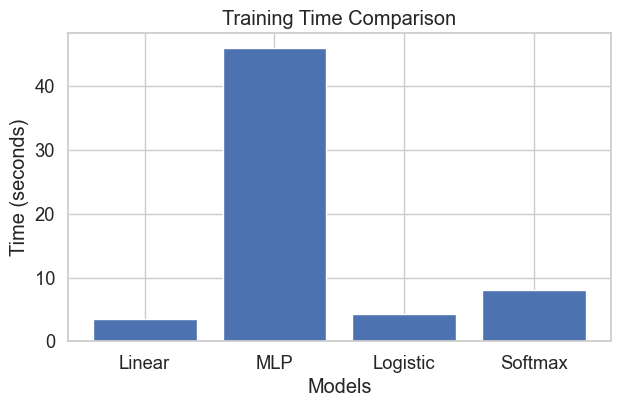

In [19]:
plt.figure(figsize=(7,4))

models = ["Linear", "MLP", "Logistic", "Softmax"]
times = [lin_time, mlp_time, log_time, soft_time]

plt.bar(models, times)

plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Models")

plt.show()

In [20]:
def mse(y, yp): return np.mean((y-yp)**2)
def rmse(y, yp): return np.sqrt(mse(y, yp))
def mae(y, yp): return np.mean(np.abs(y-yp))
def r2(y, yp):
    ss_res = np.sum((y-yp)**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    return 1 - (ss_res/ss_tot)

# Predictions
y_pred_lin = lin.predict(X_test)
y_pred_mlp = mlp.predict(X_test)

print("----- Linear Regression -----")
print("MSE:", mse(y_reg_test, y_pred_lin))
print("RMSE:", rmse(y_reg_test, y_pred_lin))
print("MAE:", mae(y_reg_test, y_pred_lin))
print("R2:", r2(y_reg_test, y_pred_lin))

print("\n----- MLP Regression -----")
print("MSE:", mse(y_reg_test, y_pred_mlp))
print("RMSE:", rmse(y_reg_test, y_pred_mlp))
print("MAE:", mae(y_reg_test, y_pred_mlp))
print("R2:", r2(y_reg_test, y_pred_mlp))

----- Linear Regression -----
MSE: 362.31472330281804
RMSE: 19.034566538348543
MAE: 10.312679902491093
R2: 0.9027688533864072

----- MLP Regression -----
MSE: 266.9694277695579
RMSE: 16.33919911652826
MAE: 10.96813307733101
R2: 0.9283558135971369


### Regression error comparison plots

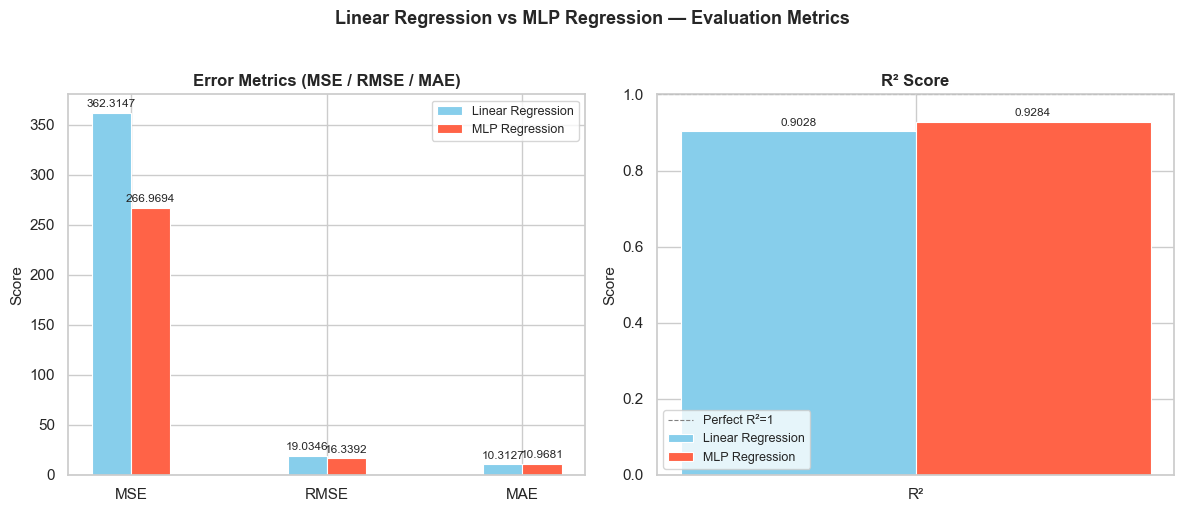

In [21]:
metrics_error = {
    "MSE":  [mse(y_reg_test, y_pred_lin),  mse(y_reg_test, y_pred_mlp)],
    "RMSE": [rmse(y_reg_test, y_pred_lin), rmse(y_reg_test, y_pred_mlp)],
    "MAE":  [mae(y_reg_test, y_pred_lin),  mae(y_reg_test, y_pred_mlp)],
}
metrics_r2 = {
    "R²": [r2(y_reg_test, y_pred_lin), r2(y_reg_test, y_pred_mlp)],
}

colors = ["skyblue", "tomato"]
width  = 0.2

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def plot_grouped_bars(ax, data, title):
    names    = list(data.keys())
    lin_vals = [data[m][0] for m in names]
    mlp_vals = [data[m][1] for m in names]
    x        = np.arange(len(names))

    bars1 = ax.bar(x - width/2, lin_vals, width, label="Linear Regression",
                   color=colors[0], edgecolor="white", linewidth=0.8)
    bars2 = ax.bar(x + width/2, mlp_vals, width, label="MLP Regression",
                   color=colors[1], edgecolor="white", linewidth=0.8)

    # Value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(lin_vals + mlp_vals) * 0.01,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8.5)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(lin_vals + mlp_vals) * 0.01,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

# --- Subplot 1: Error Metrics ---
plot_grouped_bars(ax1, metrics_error, "Error Metrics (MSE / RMSE / MAE)")

# --- Subplot 2: R² Score ---
plot_grouped_bars(ax2, metrics_r2, "R² Score")
ax2.set_ylim(0, 1)                        # R² always in [0, 1]
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Perfect R²=1")
ax2.legend(fontsize=9)

fig.suptitle("Linear Regression vs MLP Regression — Evaluation Metrics",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("regression_metrics_comparison.png", bbox_inches="tight")
plt.show()

In [22]:
# Evaluation functions
def accuracy(y, yp):
    return np.mean(y.flatten()==yp.flatten())

def precision(y, yp):
    tp = np.sum((y==1)&(yp==1))
    fp = np.sum((y==0)&(yp==1))
    return tp/(tp+fp+1e-8)

def recall(y, yp):
    tp = np.sum((y==1)&(yp==1))
    fn = np.sum((y==1)&(yp==0))
    return tp/(tp+fn+1e-8)

def f1(y, yp):
    p = precision(y, yp)
    r = recall(y, yp)
    return 2*p*r/(p+r+1e-8)

In [23]:
y_pred_log = log.predict(X_test)

print("----- Logistic Regression -----")
print("Accuracy:", accuracy(y_bin_test, y_pred_log))
print("Precision:", precision(y_bin_test, y_pred_log))
print("Recall:", recall(y_bin_test, y_pred_log))
print("F1 Score:", f1(y_bin_test, y_pred_log))

----- Logistic Regression -----
Accuracy: 0.90075
Precision: 0.8415037593959654
Recall: 0.9128874388224703
F1 Score: 0.8757433439883225


In [24]:
def multiclass_metrics(y_true, y_pred, num_classes):
    precision_list = []
    recall_list = []
    f1_list = []

    for c in range(num_classes):
        tp = np.sum((y_true==c) & (y_pred==c))
        fp = np.sum((y_true!=c) & (y_pred==c))
        fn = np.sum((y_true==c) & (y_pred!=c))

        precision = tp/(tp+fp+1e-8)
        recall = tp/(tp+fn+1e-8)
        f1 = 2*precision*recall/(precision+recall+1e-8)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    return np.mean(precision_list), np.mean(recall_list), np.mean(f1_list)

In [25]:
y_pred_soft = soft.predict(X_test)

acc_soft = accuracy(y_mul_test, y_pred_soft)
prec_soft, rec_soft, f1_soft = multiclass_metrics(
    y_mul_test.flatten(),
    y_pred_soft.flatten(),
    num_classes=3
)

print("----- Softmax Regression -----")
print("Accuracy:", acc_soft)
print("Precision:", prec_soft)
print("Recall:", rec_soft)
print("F1 Score:", f1_soft)

----- Softmax Regression -----
Accuracy: 0.80525
Precision: 0.783616915687762
Recall: 0.7718709646586639
F1 Score: 0.7766823008058034


### Loss comparison plots

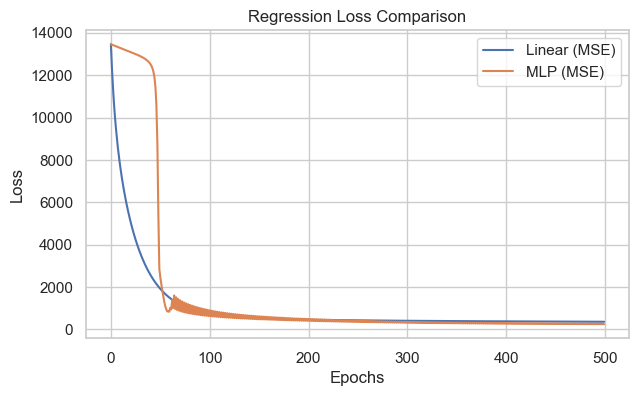

In [26]:
plt.figure(figsize=(7,4))

plt.plot(lin.loss_history, label="Linear (MSE)")
plt.plot(mlp.loss_history, label="MLP (MSE)")

plt.title("Regression Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

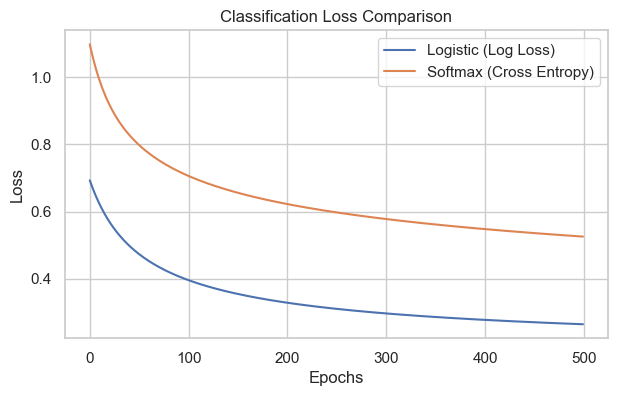

In [27]:
plt.figure(figsize=(7,4))

plt.plot(log.loss_history, label="Logistic (Log Loss)")
plt.plot(soft.loss_history, label="Softmax (Cross Entropy)")

plt.title("Classification Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

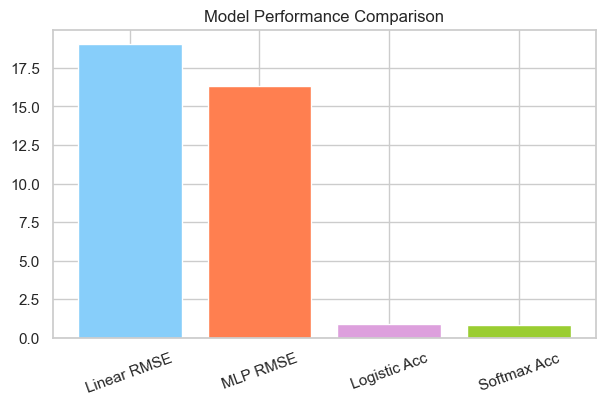

In [28]:
plt.figure(figsize=(7,4))

labels = ["Linear RMSE","MLP RMSE","Logistic Acc","Softmax Acc"]

values = [
    rmse(y_reg_test, y_pred_lin),
    rmse(y_reg_test, y_pred_mlp),
    accuracy(y_bin_test, y_pred_log),
    accuracy(y_mul_test, y_pred_soft)
]
colors = ['lightskyblue','coral','plum','yellowgreen']

plt.bar(labels, values,color=colors)
plt.xticks(rotation=20)
plt.title("Model Performance Comparison")
plt.show()

### Prediction scatter plot

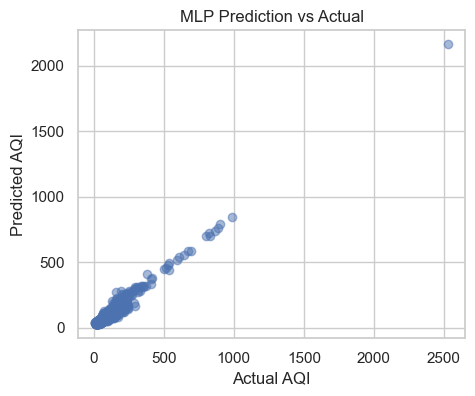

In [29]:
plt.figure(figsize=(5,4))
plt.scatter(y_reg_test, y_pred_mlp, alpha=0.5)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("MLP Prediction vs Actual")
plt.show()

### Accuracy comparison plots

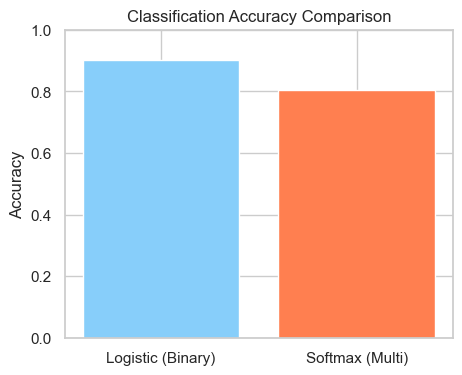

In [30]:
# Comparison plots
acc_log = accuracy(y_bin_test, y_pred_log)

plt.figure(figsize=(5,4))

models = ["Logistic (Binary)", "Softmax (Multi)"]
accuracies = [acc_log, acc_soft]
colors = ['lightskyblue', 'coral']

plt.bar(models, accuracies,color=colors)

plt.title("Classification Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

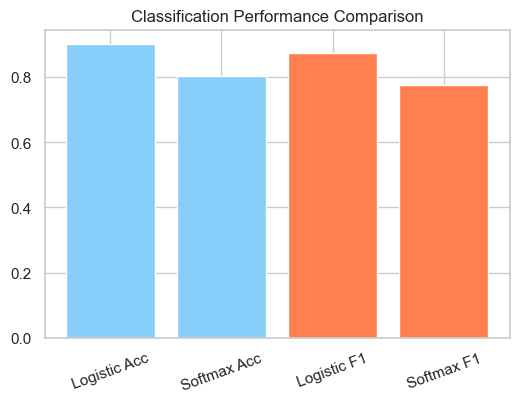

In [31]:
f1_log = f1(y_bin_test, y_pred_log)

plt.figure(figsize=(6,4))

labels = ["Logistic Acc","Softmax Acc","Logistic F1","Softmax F1"]
values = [acc_log, acc_soft, f1_log, f1_soft]
colors = ['lightskyblue', 'lightskyblue', 'coral', 'coral']

plt.bar(labels, values,color=colors)
plt.xticks(rotation=20)

plt.title("Classification Performance Comparison")
plt.show()

### Residual Comparison plots

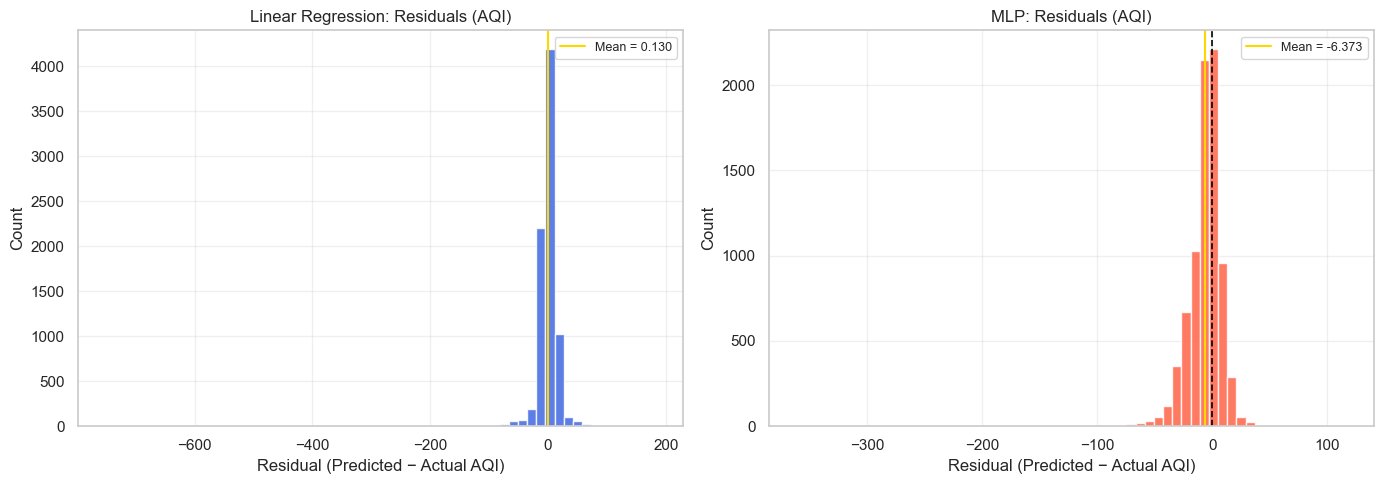

Residual distribution plots saved successfully for AQI dataset.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title, color in zip(
    axes,
    [y_pred_lin, y_pred_mlp],
    ['Linear Regression: Residuals (AQI)', 'MLP: Residuals (AQI)'],
    ['royalblue', 'tomato']
):
    residuals = preds - y_reg_test

    ax.hist(residuals, bins=60, color=color, edgecolor='white', alpha=0.85)

    # Zero error line
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2)

    # Mean residual line
    ax.axvline(np.mean(residuals), color='gold', linestyle='-',
               linewidth=1.5, label=f'Mean = {np.mean(residuals):.3f}')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Residual (Predicted − Actual AQI)')
    ax.set_ylabel('Count')

    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
     
plt.tight_layout()
plt.savefig('residual_distribution_aqi.png', bbox_inches='tight')
plt.show()

print("Residual distribution plots saved successfully for AQI dataset.")

### Confusion Matarix

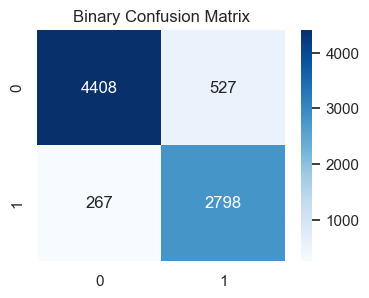

In [33]:
# Binary
def confusion_matrix_manual(y, yp):
    cm = np.zeros((2,2), dtype=int)
    for i in range(len(y)):
        cm[int(y[i])][int(yp[i])] += 1
    return cm

cm = confusion_matrix_manual(y_bin_test.flatten(), y_pred_log.flatten())

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Binary Confusion Matrix")
plt.show()

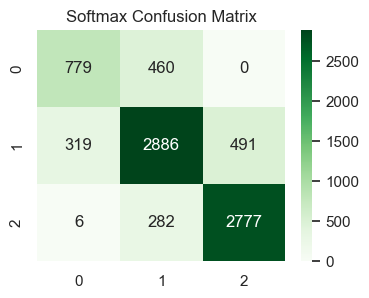

In [34]:
# Softmax Multi confusion matrix
def confusion_matrix_multi(y, yp, classes):
    cm = np.zeros((classes, classes), dtype=int)
    for i in range(len(y)):
        cm[int(y[i])][int(yp[i])] += 1
    return cm

cm_soft = confusion_matrix_multi(
    y_mul_test.flatten(),
    y_pred_soft.flatten(),
    3
)

plt.figure(figsize=(4,3))
sns.heatmap(cm_soft, annot=True, fmt='d', cmap="Greens")
plt.title("Softmax Confusion Matrix")
plt.show()

## Analysis

### Performance

The Multi-Layer Perceptron (MLP [n→64→32→1]) outperformed the Linear Regression baseline on the AQI regression task.

**Regression:**

* **Loss (MSE):** The MLP achieved significantly lower loss (~248) compared to Linear Regression (~370), indicating more accurate AQI predictions.
* **RMSE & MAE:** Both RMSE and MAE were lower for the MLP, showing that the neural network produced smaller prediction errors on average.
* **R² Score:** The MLP captured more variance in AQI values, demonstrating a better fit to the data compared to the linear model.

**Classification:**

* **Logistic Regression (Binary):** Achieved strong performance with log loss decreasing from 0.69 → 0.26, indicating effective separation between low and high pollution levels.
* **Softmax Regression (Multi-class):** Showed stable convergence with cross-entropy loss reducing from 1.09 → 0.53, successfully learning AQI category distributions.
* Logistic Regression achieved slightly higher accuracy due to the simpler binary task, while Softmax provided more detailed multi-class predictions with balanced precision and recall.

---

### MLP Performs Better

Air Quality Index depends on **complex, non-linear interactions** between environmental variables such as:

* temperature at different altitudes
* humidity and dew point
* wind speed and direction
* pollutant concentrations (PM2.5, NO₂, CO, etc.)

Linear Regression can only model **straight-line relationships**, so it cannot capture these interactions effectively.

The MLP, with hidden layers and ReLU activation:

* learns **non-linear feature interactions**
* captures **complex atmospheric relationships**
* adapts to variations across cities, seasons, and weather conditions

This allows it to model AQI much more accurately than a linear model.

---

### Computational Cost

* **Linear Regression:** Very fast training (few seconds) due to simple gradient updates.
* **Logistic / Softmax:** Moderate training time with stable convergence.
* **MLP:** Significantly slower due to:

  * multiple hidden layers
  * forward + backward propagation
  * large number of parameters

This higher cost is expected and justified by improved prediction accuracy.

---

### Training Behavior

* All models showed **smooth and consistent loss reduction**, indicating stable learning.
* Linear Regression converged quickly but plateaued at a higher loss.
* MLP showed **slower but continuous improvement**, eventually outperforming Linear Regression.
* Logistic and Softmax loss curves decreased steadily, confirming proper optimization.

---

### Challenges

* Initial MLP training showed instability due to high learning rate, which was fixed using a lower learning rate (0.001) and proper initialization.
* Large dataset size increased computation time, so sampling (20,000 rows) was used to improve efficiency.
* Numerical issues such as overflow in sigmoid and softmax were resolved using clipping and stable implementations.
* Feature preprocessing (handling NaNs, encoding categorical variables, scaling) was crucial for stable model performance.

---

### Overall Conclusion

* **MLP achieved the best regression performance**, demonstrating its ability to model complex non-linear relationships in AQI data.
* **Linear Regression remains useful** for fast and simple baseline modeling.
* **Logistic Regression is effective for binary pollution classification**, while
* **Softmax Regression provides richer multi-class AQI categorization**.

Overall, the results highlight a trade-off:

* **Baseline models → faster and simpler**
* **MLP → more accurate but computationally expensive**

Thus, MLP is the most powerful model in this assignment for AQI prediction.
